## Final Project - Purchase Intention Classification

#### Objective
Using real world session data from the Online Shoppers Purchasing Intention dataset, determine if: a browsing session will end in a purchase.

The target variable is `Revenue`, which is a boolean outcome:

1. `TRUE` means the session resulted in a purchase
2. `FALSE` means the session did not result in a purchase

The feature set is based on user behavior during a session.  It includes counts of page types visited, time spent on those page types, bounce and exit rates, seasonal timing, traffic source, and visitor profile information.

This gives a practical supervised classification problem.  The value in this analysis is that it can help identify which parts of the browsing journey align with a purchase and which parts appear to create friction.

One major point from the project discussion is possible data leakage.  The feature `PageValues` looks highly predictive, but it may also be too closely tied to post-conversion behavior.  To account for that, the models will be run in 2 branches: with `PageValues` and without `PageValues`.

#### Analysis Plan
- Split the dataset into a training set and testing set (80/20)
- Perform exploratory data analysis to understand the shape of the data, the class balance, and a few important behavioral patterns
- Use one hot encoding for categorical features and scaling where appropriate in a shared preprocessing pipeline
- Fit Logistic Regression, Decision Tree, and Random Forest models
- Use cross validation to tune each model and compare performance more reliably
- Evaluate the models using confusion matrix, accuracy, precision, recall, F1-score, and ROC AUC
- Compare results with and without `PageValues` to help determine if leakage is affecting the outcome
- Provide overall summary, model selection, and next steps

The main objective is to use features that do not give away the answer directly.  Some features are stronger than others, though the overall goal is still the same: determine whether user behavior during the session contains enough signal to predict a purchase with a reasonable degree of confidence.

#### Data Retrieval

This dataset was pulled from the UCI Machine Learning Repository and contains 12,300 sessions from an online shopping site.

The dataset is already well structured, though there are still a few preprocessing decisions to make here:

- inspect for missing values and duplicated rows
- convert boolean style fields into numeric form for modeling
- separate numeric and categorical features so the preprocessing pipeline is explicit
- run a separate branch of the analysis without `PageValues`

12,300 sessions is a strong sample size for this prediction problem.  Given the variance expected in user behavior, my thinking is that a larger dataset helps the model stabilize and gives a more reliable comparison across the different classifiers.

It is also a good fit for the final project because it contains a mix of continuous, count based, categorical, and binary features, which allows for meaningful preprocessing and model comparison.

#### Feature Notes

A few feature groups are worth calling out before the analysis starts:

- `Administrative`, `Informational`, and `ProductRelated` count the number of those page types visited in the session
- the matching duration fields measure how long the user spent on those page types
- `BounceRates` and `ExitRates` give signals about low engagement or the tendency to leave a page
- `PageValues` is a value based feature tied closely to transaction behavior, which is why it is treated as a leakage candidate
- `Month`, `TrafficType`, and `VisitorType` may capture seasonal effects, acquisition source, and user familiarity with the site
- `Revenue` is the target variable and will be modeled as 1 for purchase and 0 for no purchase

These features give a reasonable mix of user engagement, session context, and visitor profile information.

In [14]:
# setup standard imports for data analysis and visualization
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling and evaluation
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


# helper function to print the shape and quick class balance of a dataframe
def summarize_dataset(df, target_column):
    print(f"rows: {df.shape[0]}")
    print(f"columns: {df.shape[1]}")
    print("\nclass balance:")
    print(df[target_column].value_counts(normalize=True).rename("proportion"))


# helper function to evaluate a fitted classifier on the held out testing set
def evaluate_model(model, X_test, y_test, label):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": label,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions),
        "roc_auc": roc_auc_score(y_test, probabilities),
    }

    print(label)
    print(pd.Series(metrics).drop("model").round(4))
    print("\nclassification report")
    print(classification_report(y_test, predictions, digits=4))

    return metrics, predictions, probabilities

#### Data Preprocessing

Before fitting any model, first verify the condition of the dataset and make a few explicit preprocessing decisions.

- check the dimensions, data types, missing values, and duplicates
- convert the boolean style fields into numeric labels where needed
- keep the dataframe intact for EDA
- prepare numeric and categorical feature lists for the modeling pipeline

Unlike the first project, there is no strong reason to manually remove outliers up front.  Tree based models can tolerate skew fairly well, and the scaling step in the pipeline will help Logistic Regression handle the large magnitude differences between features such as durations and bounce rates.

In [4]:
data_path = "online-shoppers-intention.csv"
df = pd.read_csv(data_path)

# make a working copy and convert boolean style values into numeric form
working_df = df.copy()
working_df["Weekend"] = working_df["Weekend"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
working_df["Revenue"] = working_df["Revenue"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})

numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Weekend",
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
]

target = "Revenue"

duplicate_rows = working_df.duplicated().sum()
working_df = working_df.drop_duplicates().reset_index(drop=True)

print("missing values by column:")
print(working_df.isna().sum())
print("\nduplicate rows removed:", duplicate_rows)
print()
summarize_dataset(working_df, target)

missing values by column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

duplicate rows removed: 125

rows: 12205
columns: 18

class balance:
Revenue
0    0.843671
1    0.156329
Name: proportion, dtype: float64


A first pass shows the dataset is already in strong shape for modeling. The most important detail here is class balance. We should expect more `FALSE` sessions than `TRUE` sessions, since most browsing sessions do not convert into a purchase.

That imbalance is exactly why accuracy alone is not enough. A model could predict mostly non-purchase sessions and still post a decent accuracy score. For this project, F1-score and ROC AUC will help keep the evaluation more honest.

#### Exploratory Data Analysis

The next step is to visualize a few patterns that should help with the classification problem:

- class balance for `Revenue`
- purchase rate by month to check seasonality
- purchase rate by visitor type to see if returning visitors behave differently
- correlation among the numeric features

This will not fully explain the model, but it should help us understand what signals are likely to matter most.

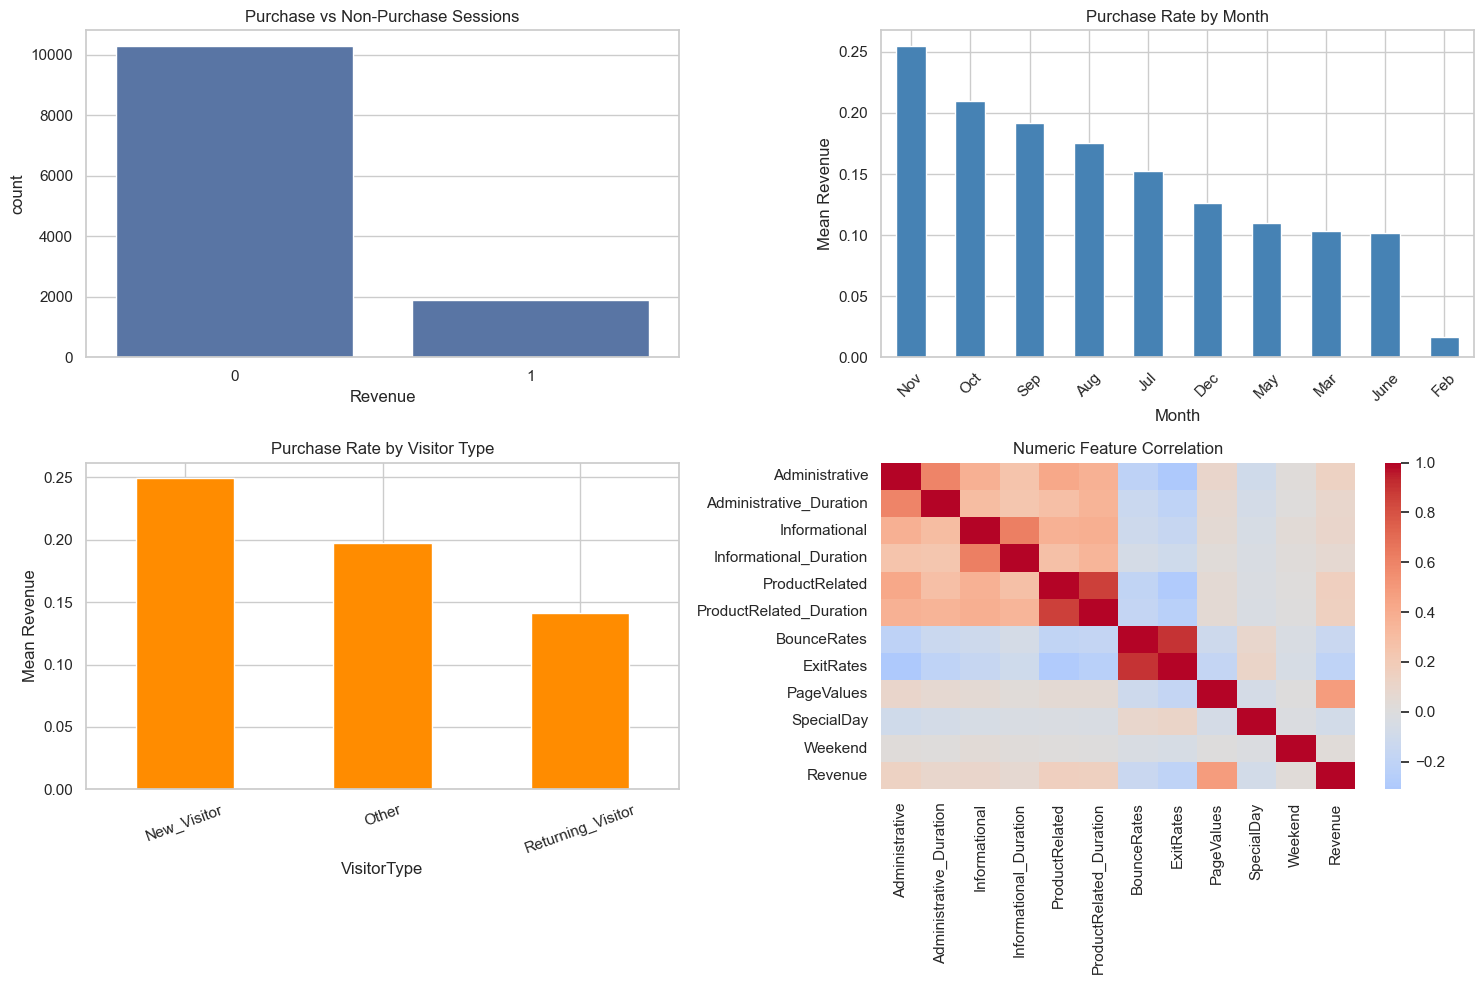

Month
Nov     0.254863
Oct     0.209472
Sep     0.191964
Aug     0.175520
Jul     0.152778
Dec     0.126612
May     0.109643
Mar     0.103226
June    0.101754
Feb     0.016575
Name: purchase_rate, dtype: float64

In [10]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=working_df, x="Revenue", ax=axes[0, 0])
axes[0, 0].set_title("Purchase vs Non-Purchase Sessions")
axes[0, 0].set_xlabel("Revenue")

month_rates = (
    working_df.groupby("Month")["Revenue"]
    .mean()
    .reindex(month_order)
    .dropna()
    .sort_values(ascending=False)
)
month_rates.plot(kind="bar", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Purchase Rate by Month")
axes[0, 1].set_ylabel("Mean Revenue")
axes[0, 1].tick_params(axis="x", rotation=45)

visitor_rates = working_df.groupby("VisitorType")["Revenue"].mean().sort_values(ascending=False)
visitor_rates.plot(kind="bar", ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("Purchase Rate by Visitor Type")
axes[1, 0].set_ylabel("Mean Revenue")
axes[1, 0].tick_params(axis="x", rotation=20)

corr = working_df[numeric_features + [target]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Numeric Feature Correlation")

plt.tight_layout()
plt.show()

month_rates.rename("purchase_rate")

#### Training, Testing, and Modeling Strategy

Split the data into a training set and a testing set using an 80/20 split with stratification on the target variable.

The training set is used for k-fold cross validation and hyperparameter tuning.  The testing set stays isolated until the final evaluation.

The following models are used in this analysis:

- `Logistic Regression` as a strong baseline for binary classification
- `Decision Tree` because it can show how combinations of session features split into purchase vs non-purchase behavior
- `Random Forest` because it should reduce overfitting and capture more complex relationships than a single tree

I am not using neural networks here.  With roughly 12k rows, the simpler models above are more interpretable and, for this project, are more appropriate to compare.

Each model is trained in 2 branches:

1. with `PageValues`
2. without `PageValues`

If performance drops sharply after removing `PageValues`, that supports the concern that the feature may contain leakage or near-leakage information.

In [6]:
X = working_df.drop(columns=[target])
y = working_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"training set size: {len(X_train)}")
print(f"testing set size:  {len(X_test)}")


# build a preprocessing object so the same transformations are reused consistently
# note: scaling is mainly needed for Logistic Regression, but using one pipeline keeps comparison fair
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def build_preprocessor(include_page_values=True):
    selected_numeric = numeric_features.copy()
    if not include_page_values:
        selected_numeric = [feature for feature in selected_numeric if feature != "PageValues"]

    selected_features = selected_numeric + categorical_features

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                selected_numeric,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )

    return preprocessor, selected_features


def build_searches(include_page_values=True):
    preprocessor, selected_features = build_preprocessor(include_page_values=include_page_values)

    searches = {
        "Logistic Regression": GridSearchCV(
            Pipeline(
                steps=[
                    ("preprocess", preprocessor),
                    (
                        "model",
                        LogisticRegression(
                            max_iter=2000,
                            class_weight="balanced",
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            ),
            param_grid={"model__C": [0.1, 1.0, 3.0]},
            scoring="f1",
            cv=cv,
            n_jobs=-1,
        ),
        "Decision Tree": GridSearchCV(
            Pipeline(
                steps=[
                    ("preprocess", preprocessor),
                    (
                        "model",
                        DecisionTreeClassifier(
                            class_weight="balanced",
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            ),
            param_grid={
                "model__max_depth": [4, 6, 8, None],
                "model__min_samples_leaf": [1, 5, 20],
            },
            scoring="f1",
            cv=cv,
            n_jobs=-1,
        ),
        "Random Forest": GridSearchCV(
            Pipeline(
                steps=[
                    ("preprocess", preprocessor),
                    (
                        "model",
                        RandomForestClassifier(
                            n_estimators=250,
                            class_weight="balanced",
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                        ),
                    ),
                ]
            ),
            param_grid={
                "model__max_depth": [6, 10, None],
                "model__min_samples_leaf": [1, 5],
            },
            scoring="f1",
            cv=cv,
            n_jobs=-1,
        ),
    }

    return searches, selected_features

training set size: 9764
testing set size:  2441


#### Model Fitting and Cross Validation

Use 5-fold stratified cross validation with F1-score as the tuning metric.

F1-score is the main tuning metric here because the purchase class is the minority class.  A model that predicts mostly non-purchase sessions can still show a decent accuracy score, while F1-score forces the model to balance precision and recall more carefully.

The purpose of this section is to compare how the three model types behave under the same train/test split and the same evaluation setup.

In [7]:
results = []
fitted_runs = {}

feature_set_options = {
    "With PageValues": True,
    "Without PageValues": False,
}

for feature_set_label, include_page_values in feature_set_options.items():
    searches, selected_features = build_searches(include_page_values=include_page_values)
    X_train_current = X_train[selected_features]
    X_test_current = X_test[selected_features]

    for model_name, search in searches.items():
        search.fit(X_train_current, y_train)

        best_model = search.best_estimator_
        metrics, predictions, probabilities = evaluate_model(
            best_model,
            X_test_current,
            y_test,
            f"{model_name} | {feature_set_label}",
        )
        metrics["feature_set"] = feature_set_label
        metrics["cv_f1"] = search.best_score_
        metrics["best_params"] = str(search.best_params_)

        results.append(metrics)
        fitted_runs[(feature_set_label, model_name)] = {
            "search": search,
            "model": best_model,
            "X_test": X_test_current,
            "y_test": y_test,
            "predictions": predictions,
            "probabilities": probabilities,
        }

results_df = pd.DataFrame(results).sort_values(
    by=["feature_set", "f1", "roc_auc", "accuracy"],
    ascending=[True, False, False, False],
).reset_index(drop=True)

results_df[["feature_set", "model", "cv_f1", "accuracy", "precision", "recall", "f1", "roc_auc", "best_params"]]

Logistic Regression | With PageValues
accuracy     0.8492
precision    0.5118
recall       0.7932
f1           0.6222
roc_auc      0.9108
dtype: object

classification report
              precision    recall  f1-score   support

           0     0.9573    0.8596    0.9058      2059
           1     0.5118    0.7932    0.6222       382

    accuracy                         0.8492      2441
   macro avg     0.7345    0.8264    0.7640      2441
weighted avg     0.8876    0.8492    0.8614      2441

Decision Tree | With PageValues
accuracy     0.8583
precision    0.5291
recall        0.856
f1            0.654
roc_auc      0.9259
dtype: object

classification report
              precision    recall  f1-score   support

           0     0.9698    0.8587    0.9109      2059
           1     0.5291    0.8560    0.6540       382

    accuracy                         0.8583      2441
   macro avg     0.7495    0.8573    0.7824      2441
weighted avg     0.9009    0.8583    0.8707      2441



/Users/freebird/Development/IIT/statistical learning/projects/final/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/freebird/Development/IIT/statistical learning/projects/final/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/freebird/Development/IIT/statistical learning/projects/final/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-le

Random Forest | With PageValues
accuracy     0.8787
precision     0.586
recall        0.767
f1           0.6644
roc_auc      0.9301
dtype: object

classification report
              precision    recall  f1-score   support

           0     0.9541    0.8995    0.9260      2059
           1     0.5860    0.7670    0.6644       382

    accuracy                         0.8787      2441
   macro avg     0.7701    0.8332    0.7952      2441
weighted avg     0.8965    0.8787    0.8851      2441

Logistic Regression | Without PageValues
accuracy     0.6493
precision    0.2789
recall       0.7827
f1           0.4113
roc_auc       0.755
dtype: object

classification report
              precision    recall  f1-score   support

           0     0.9394    0.6246    0.7503      2059
           1     0.2789    0.7827    0.4113       382

    accuracy                         0.6493      2441
   macro avg     0.6091    0.7036    0.5808      2441
weighted avg     0.8360    0.6493    0.6972      2441


,feature_set,model,cv_f1,accuracy,precision,recall,f1,roc_auc,best_params
0,With PageValues,Random Forest | With PageValues,0.675399,0.878738,0.586000,0.767016,0.664399,0.930071,"{'model__max_depth': None, 'model__min_samples..."
1,With PageValues,Decision Tree | With PageValues,0.642438,0.858255,0.529126,0.856021,0.654000,0.925897,"{'model__max_depth': 4, 'model__min_samples_le..."
2,With PageValues,Logistic Regression | With PageValues,0.611820,0.849242,0.511824,0.793194,0.622177,0.910798,{'model__C': 0.1}
3,Without PageValues,Random Forest | Without PageValues,0.417741,0.699713,0.303030,0.706806,0.424195,0.781675,"{'model__max_depth': 10, 'model__min_samples_l..."
4,Without PageValues,Logistic Regression | Without PageValues,0.391562,0.649324,0.278918,0.782723,0.411279,0.754982,{'model__C': 3.0}
5,Without PageValues,Decision Tree | Without PageValues,0.403864,0.730848,0.312415,0.599476,0.410762,0.739771,"{'model__max_depth': 4, 'model__min_samples_le..."


#### Model Comparison Analysis

This table gives two useful comparisons at the same time:

- how the three model types compare against each other
- how much the inclusion of `PageValues` changes the results

If the ranking stays similar but the scores with `PageValues` are much stronger, that suggests the feature is carrying unusually strong information about the target outcome.

In [8]:
comparison_table = results_df[["feature_set", "model", "cv_f1", "accuracy", "precision", "recall", "f1", "roc_auc"]].copy()
comparison_table.iloc[:, 2:] = comparison_table.iloc[:, 2:].round(4)
comparison_table

,feature_set,model,cv_f1,accuracy,precision,recall,f1,roc_auc
0,With PageValues,Random Forest | With PageValues,0.6754,0.8787,0.5860,0.7670,0.6644,0.9301
1,With PageValues,Decision Tree | With PageValues,0.6424,0.8583,0.5291,0.8560,0.6540,0.9259
2,With PageValues,Logistic Regression | With PageValues,0.6118,0.8492,0.5118,0.7932,0.6222,0.9108
3,Without PageValues,Random Forest | Without PageValues,0.4177,0.6997,0.3030,0.7068,0.4242,0.7817
4,Without PageValues,Logistic Regression | Without PageValues,0.3916,0.6493,0.2789,0.7827,0.4113,0.7550
5,Without PageValues,Decision Tree | Without PageValues,0.4039,0.7308,0.3124,0.5995,0.4108,0.7398


In [9]:
summary_by_feature_set = (
    comparison_table.sort_values(["feature_set", "f1", "roc_auc", "accuracy"], ascending=[True, False, False, False])
    .groupby("feature_set", as_index=False)
    .first()
)

print("best model within each feature set")
print(summary_by_feature_set.to_string(index=False))

print("\nfull comparison table")
print(comparison_table.to_string(index=False))

best model within each feature set
       feature_set                              model  cv_f1  accuracy  precision  recall     f1  roc_auc
   With PageValues    Random Forest | With PageValues 0.6754    0.8787      0.586  0.7670 0.6644   0.9301
Without PageValues Random Forest | Without PageValues 0.4177    0.6997      0.303  0.7068 0.4242   0.7817

full comparison table
       feature_set                                    model  cv_f1  accuracy  precision  recall     f1  roc_auc
   With PageValues          Random Forest | With PageValues 0.6754    0.8787     0.5860  0.7670 0.6644   0.9301
   With PageValues          Decision Tree | With PageValues 0.6424    0.8583     0.5291  0.8560 0.6540   0.9259
   With PageValues    Logistic Regression | With PageValues 0.6118    0.8492     0.5118  0.7932 0.6222   0.9108
Without PageValues       Random Forest | Without PageValues 0.4177    0.6997     0.3030  0.7068 0.4242   0.7817
Without PageValues Logistic Regression | Without PageValues 0.39

The model comparison shows 2 clear results.

First, `Random Forest` performs best in both branches of the analysis.  That supports the idea from the project discussion that user behavior likely contains non-linear interactions that a single linear boundary does not capture as well.

Second, the scores drop sharply when `PageValues` is removed.  The best F1-score falls from about 0.66 to about 0.42, and ROC AUC falls from about 0.93 to about 0.78.  That is too large of a drop to ignore and strongly suggests that `PageValues` contains information that is unusually close to the target event.

For that reason, I would treat the `Without PageValues` branch as the more realistic estimate of true predictive performance, even though the `With PageValues` branch scores higher.

#### Confusion Matrix Comparison

Since Random Forest performed best in both branches, the next step is to compare the confusion matrices for the best model with and without `PageValues`.

This makes it easier to see where the model gains or loses performance. In particular, we should focus on how well the model identifies actual purchase sessions, since that is the minority class.

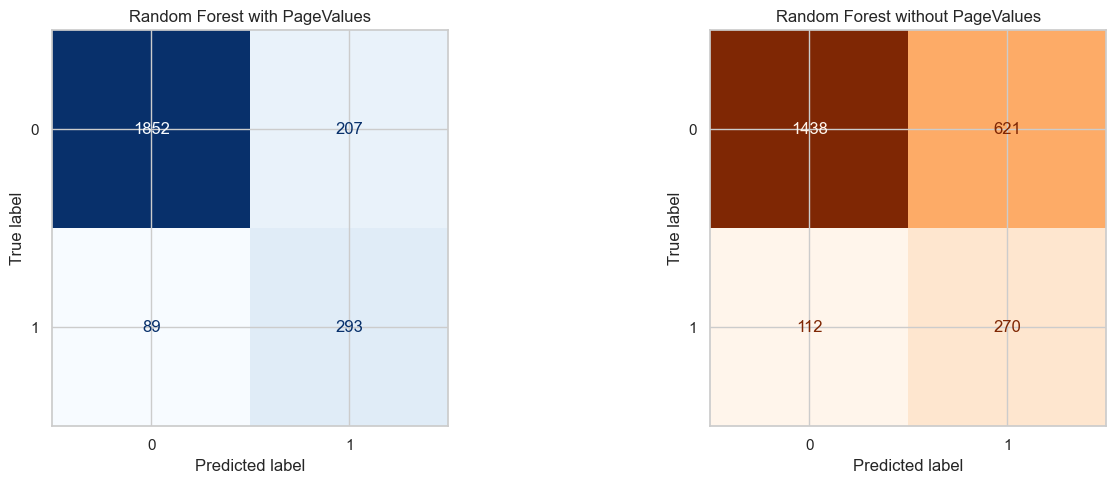

In [11]:
best_with_pagevalues = fitted_runs[("With PageValues", "Random Forest")]
best_without_pagevalues = fitted_runs[("Without PageValues", "Random Forest")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    best_with_pagevalues["y_test"],
    best_with_pagevalues["predictions"],
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
)
axes[0].set_title("Random Forest with PageValues")

ConfusionMatrixDisplay.from_predictions(
    best_without_pagevalues["y_test"],
    best_without_pagevalues["predictions"],
    ax=axes[1],
    cmap="Oranges",
    colorbar=False,
)
axes[1].set_title("Random Forest without PageValues")

plt.tight_layout()
plt.show()

#### ROC Curve Comparison

The confusion matrix gives a threshold based view of the model, but ROC curves are also useful because they show how well the model separates the classes across all possible thresholds.

To keep this focused, the plot below compares the three tuned models without `PageValues`, then overlays the best model with `PageValues` as a reference point.

This helps answer 2 questions:

- which no-leakage model separates purchasers from non-purchasers the best
- how large the gap is between the realistic branch and the branch that includes the suspicious feature

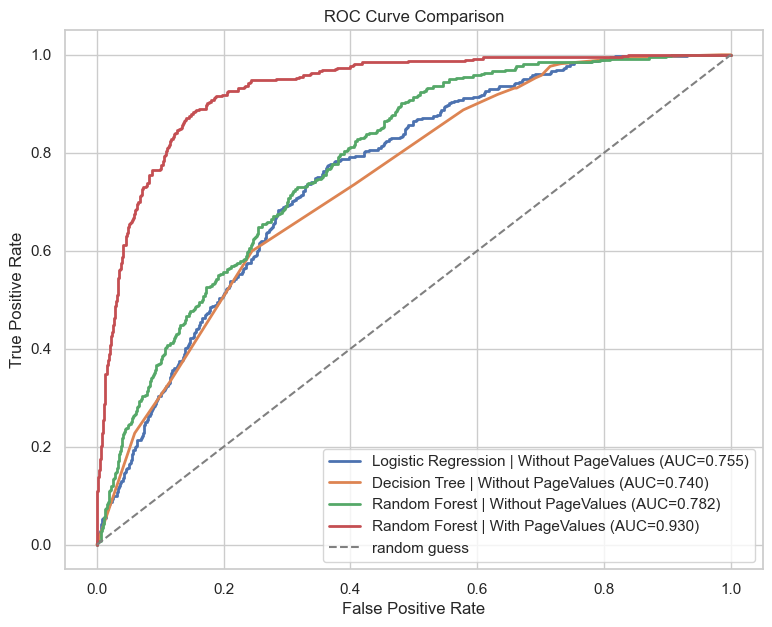

In [15]:
roc_run_keys = [
    ("Without PageValues", "Logistic Regression"),
    ("Without PageValues", "Decision Tree"),
    ("Without PageValues", "Random Forest"),
    ("With PageValues", "Random Forest"),
]

plt.figure(figsize=(9, 7))

for feature_set_name, model_name in roc_run_keys:
    run = fitted_runs[(feature_set_name, model_name)]
    fpr, tpr, _ = roc_curve(run["y_test"], run["probabilities"])
    auc_score = roc_auc_score(run["y_test"], run["probabilities"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} | {feature_set_name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="random guess")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

The ROC curves support the same ranking we saw in the metrics table.  Among the no-leakage models, `Random Forest` gives the strongest class separation overall.  `Logistic Regression` and `Decision Tree` still perform above the random baseline, though both lag behind in ROC AUC.

The larger point is the gap between the two Random Forest curves.  When `PageValues` is included, the model separates the classes much more cleanly.  That is useful from a detection standpoint, but it also reinforces the concern that the feature may be carrying information that would not be appropriate in a real prediction setting.

The confusion matrices reinforce the earlier conclusion. With `PageValues`, the model does a much better job identifying the positive purchase class while still keeping strong overall accuracy.

Once `PageValues` is removed, the model still finds many purchasers, but it produces noticeably more false positives and the precision drops. That makes the model less trustworthy if the goal is to target likely purchasers without over-targeting sessions that will not convert.

Even so, the no-leakage model still has value. It shows that browsing behavior, visitor type, seasonality, and traffic context carry real signal, even after removing the suspicious feature.

#### Decision Tree Visualization

Although Random Forest produced the best overall scores, the Decision Tree is still useful because it is easier to interpret visually.

To keep the diagram readable, the plot below uses the tuned Decision Tree from the `Without PageValues` branch and limits the displayed depth. This gives a more practical view of the strongest early splits without overwhelming the notebook.

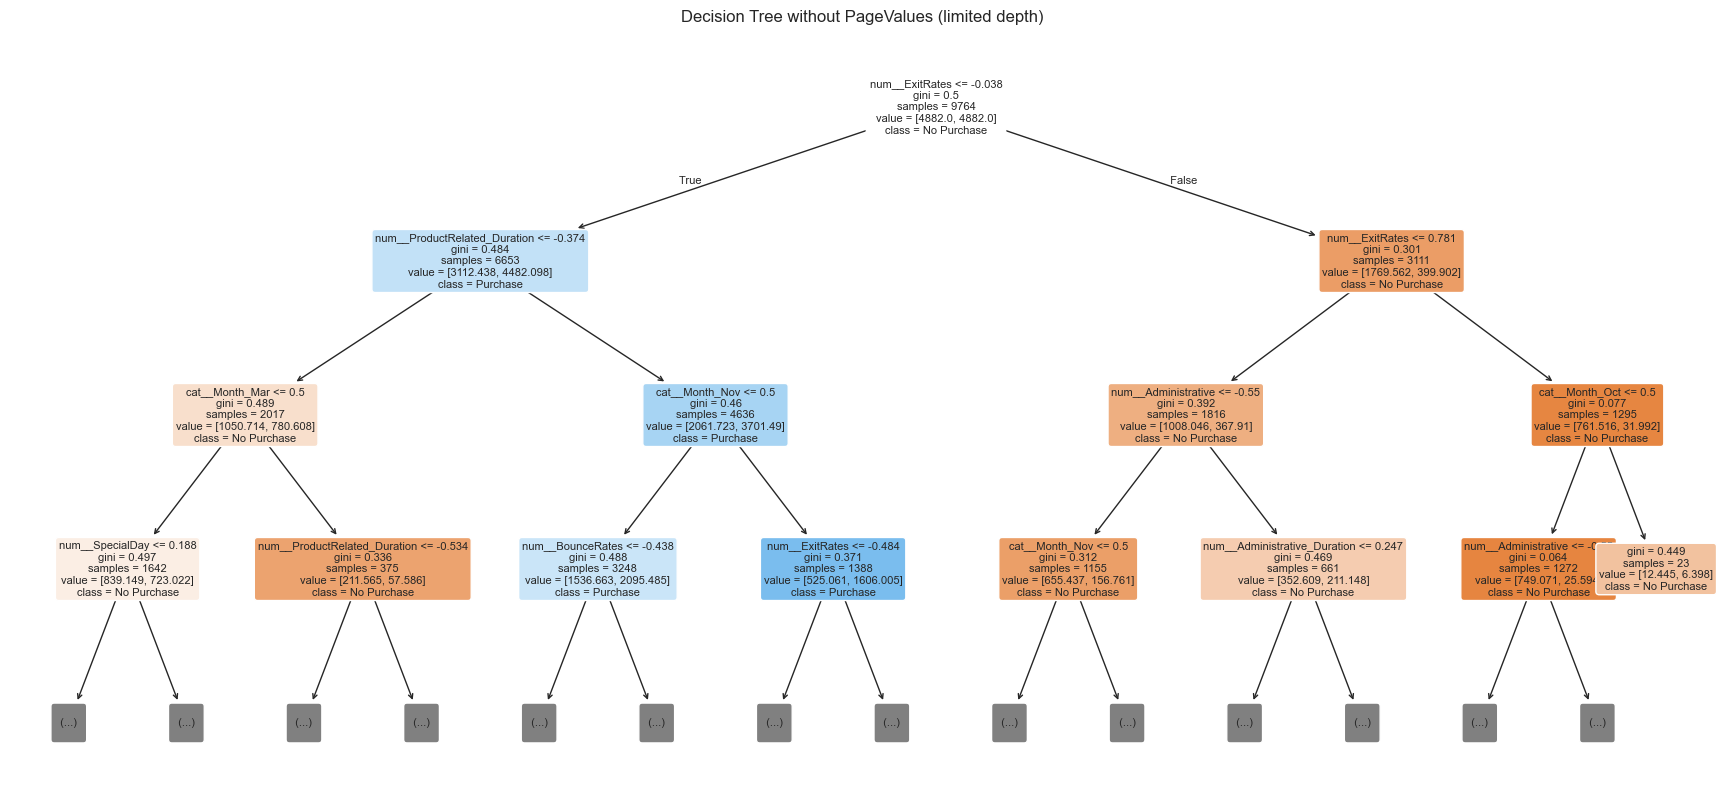

In [12]:
decision_tree_without_pagevalues = fitted_runs[("Without PageValues", "Decision Tree")]["model"]
decision_tree_preprocessor = decision_tree_without_pagevalues.named_steps["preprocess"]
decision_tree_model = decision_tree_without_pagevalues.named_steps["model"]
decision_tree_feature_names = decision_tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    decision_tree_model,
    feature_names=decision_tree_feature_names,
    class_names=["No Purchase", "Purchase"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree without PageValues (limited depth)")
plt.show()

Even with the depth limited, the tree helps show that purchase intent is not driven by a single simple rule. The splits combine page activity, exit style behavior, and visitor context. That supports the choice of Random Forest as the strongest final model, because it can average many tree structures like this one instead of relying on one path only.

#### Feature Importance Review

Feature importance gives another angle on the leakage question.

If `PageValues` dominates the feature importance ranking in the stronger model, that is consistent with the sharp score drop we saw when it was removed. It would suggest the model is leaning heavily on that one feature instead of distributing importance across broader session behavior.

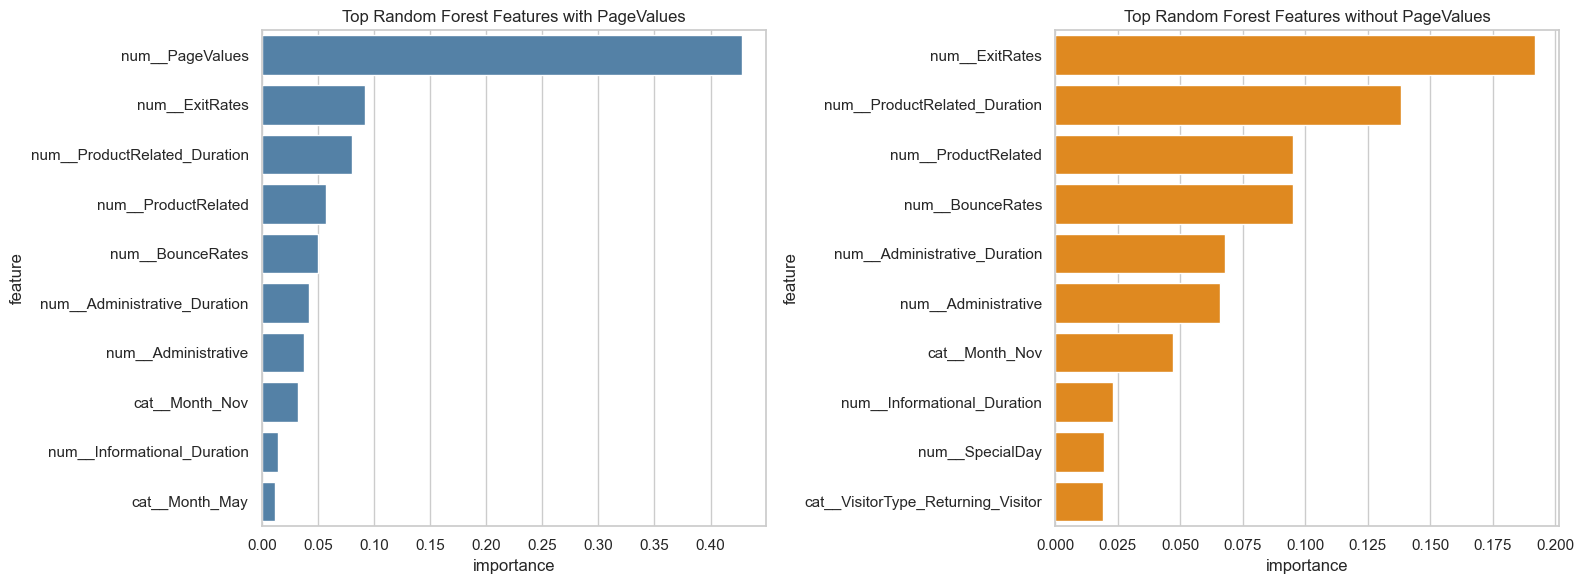

top features with PageValues
                     feature  importance
             num__PageValues    0.427866
              num__ExitRates    0.091706
num__ProductRelated_Duration    0.080693
         num__ProductRelated    0.057688
            num__BounceRates    0.050371
num__Administrative_Duration    0.042370
         num__Administrative    0.037287
              cat__Month_Nov    0.032750
 num__Informational_Duration    0.014756
              cat__Month_May    0.011696

top features without PageValues
                           feature  importance
                    num__ExitRates    0.191962
      num__ProductRelated_Duration    0.138111
               num__ProductRelated    0.095160
                  num__BounceRates    0.095035
      num__Administrative_Duration    0.067900
               num__Administrative    0.065793
                    cat__Month_Nov    0.047187
       num__Informational_Duration    0.023135
                   num__SpecialDay    0.019552
cat__VisitorType_

In [13]:
def top_feature_importance(run_key, top_n=10):
    fitted_pipeline = fitted_runs[run_key]["model"]
    fitted_preprocessor = fitted_pipeline.named_steps["preprocess"]
    fitted_model = fitted_pipeline.named_steps["model"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": fitted_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    return importance_df.head(top_n)


importance_with = top_feature_importance(("With PageValues", "Random Forest"))
importance_without = top_feature_importance(("Without PageValues", "Random Forest"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=importance_with, x="importance", y="feature", ax=axes[0], color="steelblue")
axes[0].set_title("Top Random Forest Features with PageValues")

sns.barplot(data=importance_without, x="importance", y="feature", ax=axes[1], color="darkorange")
axes[1].set_title("Top Random Forest Features without PageValues")

plt.tight_layout()
plt.show()

print("top features with PageValues")
print(importance_with.to_string(index=False))
print("\ntop features without PageValues")
print(importance_without.to_string(index=False))

The feature importance chart should be read carefully.  Importance does not prove causation, though it does show what the model relies on most.

In the `With PageValues` branch, `PageValues` dominates the ranking by a wide margin.  That is exactly what we would expect if the feature is carrying information that is very close to the final conversion event.  After that, the next most important features are `ExitRates`, `ProductRelated_Duration`, `ProductRelated`, and `BounceRates`, which are all intuitive session behavior signals.

In the `Without PageValues` branch, the importance is spread across a broader set of variables.  `ExitRates` becomes the strongest feature, followed by `ProductRelated_Duration`, `ProductRelated`, `BounceRates`, and the administrative page metrics.  `Month_Nov` also ranks highly, which fits with the seasonal signal seen earlier in the EDA.

That wider distribution is more convincing from a business standpoint.  It suggests that, without the suspicious feature, the model is learning from actual browsing behavior and seasonal context rather than leaning heavily on one near-outcome variable.

### Final Analysis and Summary

##### Challenges Faced

The biggest challenge in this project was not fitting the models.  It was deciding how to treat a feature that appears highly predictive, but may also be too closely tied to the outcome itself.

`PageValues` improved every model substantially, and the improvement was large enough that it could not be ignored.  That required running the full analysis twice so the final recommendation would not overstate the model's practical value.

A second challenge was class imbalance.  Since most sessions do not end in a purchase, a model can appear stronger than it really is if we focus only on accuracy.  That is why the evaluation emphasized confusion matrices, F1-score, and ROC AUC.

##### Model Performance

Across all six model runs, `Random Forest` produced the strongest overall performance.  With `PageValues`, it reached an accuracy of about 87.9%, an F1-score of about 0.664, and a ROC AUC of about 0.930.  Without `PageValues`, it remained the best of the three models, though performance dropped to an accuracy of about 70.0%, an F1-score of about 0.424, and a ROC AUC of about 0.782.

That gap is too large to treat as a minor difference.  It suggests that `PageValues` carries information that is very close to the target event.  For honest deployment expectations, the `Without PageValues` Random Forest is the more realistic result.

`Logistic Regression` provided a useful baseline and performed reasonably well, especially when `PageValues` was included.  `Decision Tree` performed better than Logistic Regression on recall in some cases and provided a very interpretable structure, though `Random Forest` gave the best overall balance of precision, recall, and ROC AUC.

##### Best Model Selection

If the goal is pure predictive performance inside this dataset, the best model is `Random Forest with PageValues`.

If the goal is a realistic and defensible model selection, the best model is `Random Forest without PageValues`.

That is the model I would select as the final answer for this project.  It still performs better than the other no-leakage models, and it does so while relying on a more believable mix of session behavior, engagement signals, and seasonal context.

##### Conclusion

The main lesson from this project is that predictive performance alone is not enough.  We also have to think about where the information comes from and whether the feature would be valid at prediction time.

Even after removing the possible leakage feature, the model still shows that purchase intent is related to meaningful session behavior patterns, especially engagement with product related pages, exit and bounce behavior, administrative activity, visitor context, and seasonal timing.

That makes the final result useful even though the overall accuracy drops.  It is a more honest estimate of what the model can likely do in practice.

##### Next Steps and Thoughts

- test additional models such as gradient boosting or XGBoost style methods to see if they can improve the no-leakage baseline
- engineer more session level behavioral features that are clearly available before conversion
- tune the classification threshold instead of relying on the default 0.5 cutoff, especially if recall for purchasers is more important than precision
- validate the no-leakage model on a newer time period to see how stable the patterns remain over time